In [60]:
import pandas as pd

df = pd.read_csv("../data/processed/engineered_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (5600, 19)


,failed_connection_attempts,packets_sent_per_sec,packets_recv_per_sec,tcp_connection_count,context_switch_rate,unique_dst_port_count,top_process_cpu_pct,cpu_user_pct,load_avg_1m,attack_type,is_attack,packet_rate_total,packet_spike_ratio,connection_spike_ratio,cpu_spike_ratio,process_cpu_ratio,failure_rate,port_scan_intensity,load_per_connection
0,0.0,0.0,0.0,9.0,567.0,0,0.0,6.21,0.18,crypto,1,0.0,1.002004,1.000000,1.000000,0.000000,0.0,0.0,0.018000
1,0.0,0.0,0.0,9.0,803.0,0,0.0,1.50,0.41,crypto,1,0.0,1.002004,1.000000,0.389105,0.000000,0.0,0.0,0.041000
2,0.0,0.0,0.0,10.0,893.0,0,0.0,5.68,0.41,crypto,1,0.0,1.002004,1.071429,1.272591,0.000000,0.0,0.0,0.037273
3,0.0,0.0,0.0,14.0,404.0,0,26.0,4.99,0.41,crypto,1,0.0,1.002004,1.333333,1.085963,5.210410,0.0,0.0,0.027333
4,0.0,0.0,0.0,14.0,496.0,0,59.9,2.17,0.37,crypto,1,0.0,1.002004,1.250000,0.527981,27.603559,0.0,0.0,0.024667


In [61]:
features = [
    'failure_rate',
    'port_scan_intensity',
    'process_cpu_ratio',
    'packet_spike_ratio',
    'connection_spike_ratio',   # NEW
    'cpu_spike_ratio'           # NEW
]

X = df[features]
y = df['is_attack']

print("Using features:", features)

Using features: ['failure_rate', 'port_scan_intensity', 'process_cpu_ratio', 'packet_spike_ratio', 'connection_spike_ratio', 'cpu_spike_ratio']


In [62]:
print(df.isnull().sum())

failed_connection_attempts    0
packets_sent_per_sec          0
packets_recv_per_sec          0
tcp_connection_count          0
context_switch_rate           0
unique_dst_port_count         0
top_process_cpu_pct           0
cpu_user_pct                  0
load_avg_1m                   0
attack_type                   0
is_attack                     0
packet_rate_total             0
packet_spike_ratio            0
connection_spike_ratio        0
cpu_spike_ratio               0
process_cpu_ratio             0
failure_rate                  0
port_scan_intensity           0
load_per_connection           0
dtype: int64


In [63]:
X_train = X[y == 0]   # ONLY normal data
X_test  = X           # test on full dataset

print("Train (normal only):", X_train.shape)
print("Test (full):", X_test.shape)

Train (normal only): (3900, 6)
Test (full): (5600, 6)


In [64]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Feature Transformation (Correct Placement)         ║
# ╚══════════════════════════════════════════════════════════╝

import numpy as np

for col in ['process_cpu_ratio', 'packet_spike_ratio', 'connection_spike_ratio']:
    df[col] = np.log1p(df[col])

print("Log transform applied BEFORE feature selection")

Log transform applied BEFORE feature selection


In [65]:
# Identify zero-variance features (on NORMAL data)
zero_var_cols = X_train.columns[X_train.std() == 0]

print("Dropping (zero variance):", list(zero_var_cols))

# Drop from both train and test
X_train = X_train.drop(columns=zero_var_cols)
X_test  = X_test.drop(columns=zero_var_cols)

Dropping (zero variance): ['failure_rate']


In [66]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [68]:
import numpy as np 
print("NaN in scaled data:", np.isnan(X_test_scaled).sum())

NaN in scaled data: 0


In [69]:
print(X_train.std())

port_scan_intensity       0.039124
process_cpu_ratio         0.526475
packet_spike_ratio        1.366619
connection_spike_ratio    0.067724
cpu_spike_ratio           0.924463
dtype: float64


In [70]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,        # more trees → better learning
    contamination=0.28,      # slightly more sensitive
    max_samples='auto',
    random_state=42
)

model.fit(X_train_scaled)

print("Model trained on normal data")

Model trained on normal data


In [78]:
# Get anomaly scores
scores = model.decision_function(X_test_scaled)

# Apply threshold (adjust as needed)
threshold = -0.02  # Lower = more sensitive to anomalies
y_pred = (scores < threshold).astype(int)

df['anomaly_pred'] = y_pred
df['anomaly_score'] = scores

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n")
print(confusion_matrix(y, y_pred))

print("\nClassification Report:\n")
print(classification_report(y, y_pred))

Confusion Matrix:

[[3093  807]
 [  92 1608]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.79      0.87      3900
           1       0.67      0.95      0.78      1700

    accuracy                           0.84      5600
   macro avg       0.82      0.87      0.83      5600
weighted avg       0.88      0.84      0.85      5600



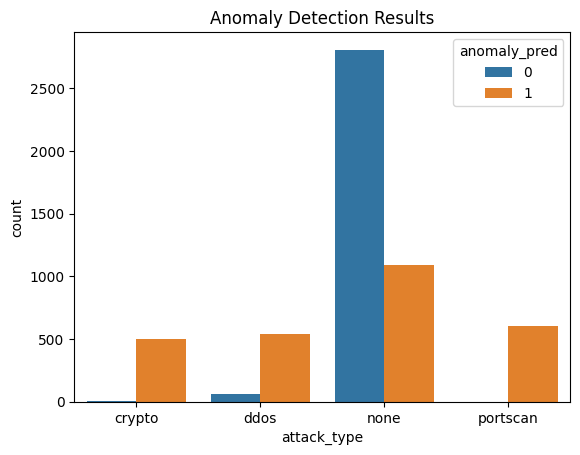

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='attack_type', hue='anomaly_pred', data=df)

plt.title("Anomaly Detection Results")
plt.show()

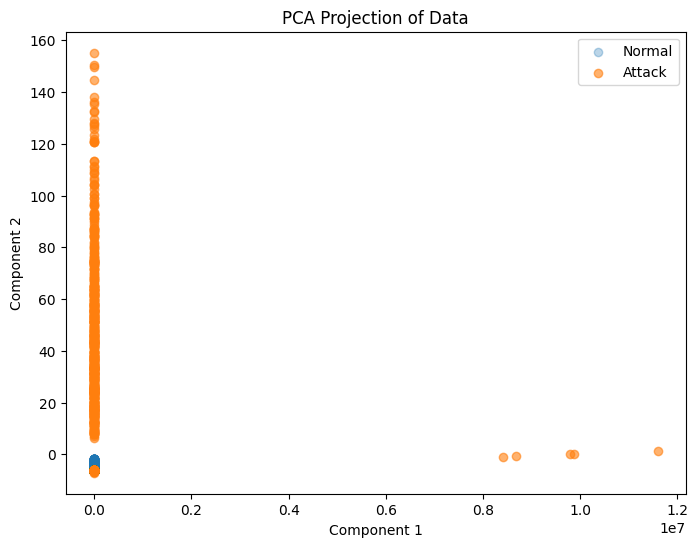

In [74]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Visualization — PCA Projection                     ║
# ╚══════════════════════════════════════════════════════════╝

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_test_scaled)

# Plot
plt.figure(figsize=(8,6))

# Normal points
plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    alpha=0.3,
    label="Normal",
)

# Attack points
plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    alpha=0.6,
    label="Attack",
)

plt.title("PCA Projection of Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()

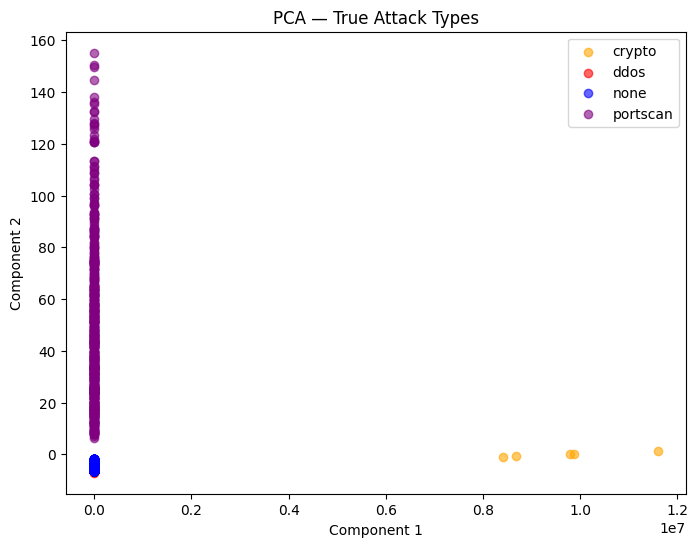

In [75]:
# ╔══════════════════════════════════════════════════════════╗
# ║      PCA — True Attack Types                            ║
# ╚══════════════════════════════════════════════════════════╝

plt.figure(figsize=(8,6))

colors = {
    'none': 'blue',
    'ddos': 'red',
    'portscan': 'purple',
    'crypto': 'orange'
}

for attack in df['attack_type'].unique():
    idx = df['attack_type'] == attack
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=attack,
        alpha=0.6,
        color=colors.get(attack, 'black')
    )

plt.title("PCA — True Attack Types")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()

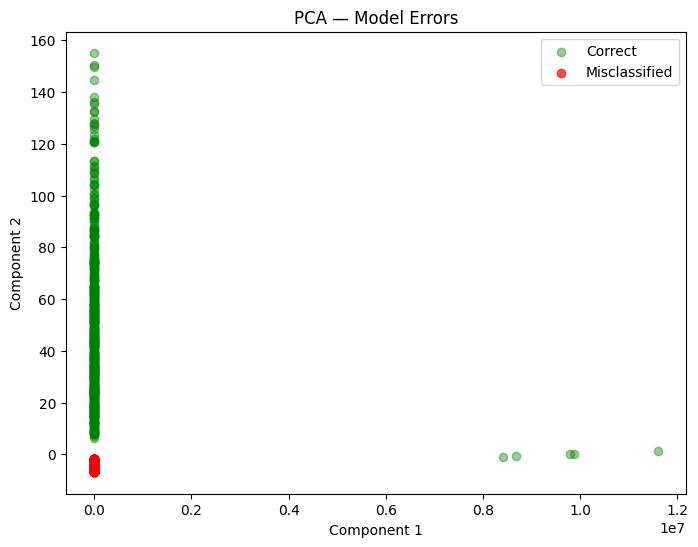

In [76]:
# ╔══════════════════════════════════════════════════════════╗
# ║      PCA — Prediction vs Reality                        ║
# ╚══════════════════════════════════════════════════════════╝

plt.figure(figsize=(8,6))

# Correct predictions
correct = (df['is_attack'] == df['anomaly_pred'])

# Plot correct points
plt.scatter(
    X_pca[correct, 0],
    X_pca[correct, 1],
    c='green',
    alpha=0.4,
    label='Correct'
)

# Plot incorrect points
plt.scatter(
    X_pca[~correct, 0],
    X_pca[~correct, 1],
    c='red',
    alpha=0.7,
    label='Misclassified'
)

plt.title("PCA — Model Errors")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()

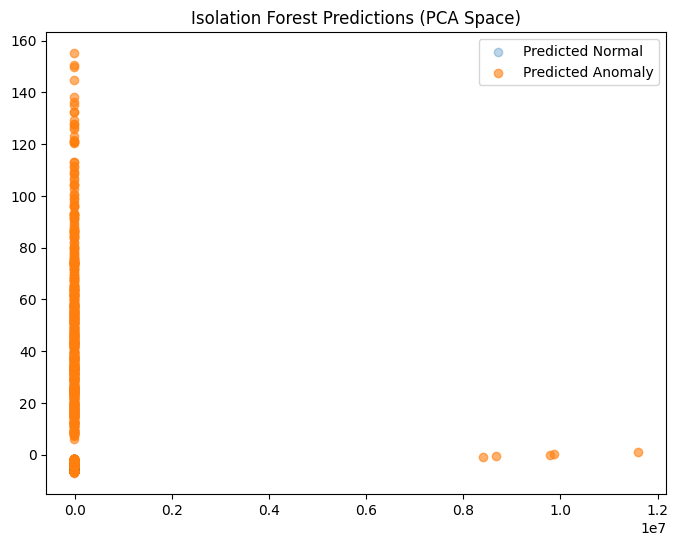

In [77]:
plt.figure(figsize=(8,6))

# Predicted normal
plt.scatter(
    X_pca[np.array(y_pred) == 0, 0],
    X_pca[np.array(y_pred) == 0, 1],
    alpha=0.3,
    label="Predicted Normal"
)

# Predicted anomaly
plt.scatter(
    X_pca[np.array(y_pred) == 1, 0],
    X_pca[np.array(y_pred) == 1, 1],
    alpha=0.6,
    label="Predicted Anomaly"
)

plt.title("Isolation Forest Predictions (PCA Space)")
plt.legend()
plt.show()